In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from hexarena.color import get_cue_movie
plt.rcParams.update({
    'figure.figsize': (4.8, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'legend.fontsize': 'small', 'axes.titlesize': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'image.interpolation': 'nearest', 'savefig.dpi': 100,
})

import numpy as np
from numpy.fft import fftfreq, ifft2

rng = np.random.default_rng()

In [66]:
# Generate the original stimulus
kappa =  0.1
cue = 0.7
num_trials = 100
num_steps = 100

original_observations = []
for i in range(num_trials):
    original_movie = get_cue_movie(
        cue = cue,
        num_steps = num_steps,
        kappa = kappa,
        rng = rng,
    )
    original_observations.append(original_movie)

original_observations = np.array(original_observations)

In [44]:
def central_crop_mask(image_or_shape, area_frac: float = 0.5, dtype=bool):
    """Return a central rectangular crop mask matching image dimensions.

    Parameters
    ----------
    image_or_shape:
        Either an array of shape (H, W) or (N, H, W), or a shape tuple (H, W).
    area_frac:
        Fraction of total pixels (area) to include in the crop (0 < area ≤ 1).
        The crop preserves aspect ratio; e.g., 0.5 means the middle 50% of pixels.
    dtype:
        Output dtype for the mask (default bool). If not bool, mask values are 0/1.

    Returns
    -------
    mask:
        Array of shape (H, W) with the central rectangle set to True/1.
    slices:
        Tuple of (yslice, xslice) that can be used to crop arrays as arr[:, y, x].
    """
    if not (0 < area_frac <= 1):
        raise ValueError("area_frac must be in (0, 1].")

    # Determine spatial dimensions (H, W)
    if isinstance(image_or_shape, tuple):
        if len(image_or_shape) != 2:
            raise ValueError("shape tuple must be (H, W)")
        H, W = image_or_shape
    else:
        arr = np.asarray(image_or_shape)
        H, W = arr.shape[-2:]

    # Compute crop size preserving aspect ratio
    scale = float(area_frac) ** 0.5
    crop_h = max(1, int(round(H * scale)))
    crop_w = max(1, int(round(W * scale)))

    # Center the crop
    top = (H - crop_h) // 2
    left = (W - crop_w) // 2
    y_slice = slice(top, top + crop_h)
    x_slice = slice(left, left + crop_w)

    # Build mask
    mask = np.zeros((H, W), dtype=dtype)
    fill_value = True if dtype is bool else 1
    mask[y_slice, x_slice] = fill_value

    return mask, (y_slice, x_slice)


In [67]:
# Create central crop mask for the movie frames
mask_2d, (ys, xs) = central_crop_mask(original_observations, area_frac=0.5)

# Example 1: slice to get cropped movie
cropped_observations = original_observations[:, :, ys, xs]

# Example 2: masked movie (zeros out pixels outside crop)
masked_observations = original_observations * mask_2d[np.newaxis, np.newaxis, :, :]

mask_2d.shape, cropped_observations.shape, masked_observations.shape, original_observations.shape

((128, 96), (100, 100, 91, 68), (100, 100, 128, 96), (100, 100, 128, 96))

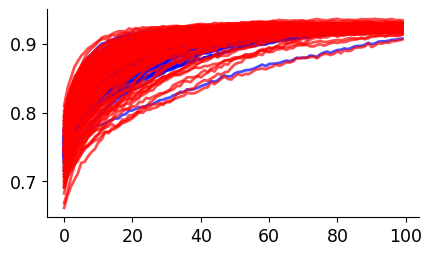

In [ ]:
# Take crops and average over the pixels
#TODO: concatenate two arrays along with color values and randomize order
plt.plot(original_observations.mean(axis=(2,3)).T, label='original', c = 'blue', alpha = 0.5)
plt.plot(cropped_observations.mean(axis=(2,3)).T, label='cropped', c = 'red', alpha = 0.5)
plt.show()